In [69]:
# E-commerce sgementation system
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
df = pd.read_csv("smartcart_customers.csv")

In [71]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [72]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data preprocessing

1. Handle missing values

In [73]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [74]:
df.isnull().sum()
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


# Feature Engineering

In [75]:
#Handling dates
#1) year-birth converting to age as it more useful 
df["Age"] = 2026 - df["Year_Birth"]
#2) date_customer (joining date) converting to custonmer tenure date 
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True) #converting to m-d-yyyy format as requried by pandas

reference_date = df["Dt_Customer"].max() #taking recent customer's date and subtracting from that 

df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days 


In [76]:
#Spending
#combing products into a new feature total_Spending 
df["Total_Spending"] = df["MntWines"] +df["MntFruits"] +df["MntMeatProducts"] +df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

#Children
#combining features to create a new feature total_children 
df["total_children"] = df["Kidhome"] + df["Teenhome"]

In [77]:
#Education
df["Education"].value_counts()

#Undergraducate - basic, 2nd cycle , Graduate - graducation , Postgraducate - phd,master
df["Education"] = df["Education"].replace({
    "Basic":"Undergraduate","2n Cycle":"Undergraduate",
    "Graduation":"Graduate",
    "Master":"Postgraduate", "PhD":"Postgraduate"
})

In [78]:
#Marital Status
df["Marital_Status"].value_counts()

df["Living_With"] = df["Marital_Status"].replace({
    "Married":"Partner","Together":"Partner",
    "Single":"Alone","Divorced":"Alone",
    "Widow":"Alone", "Absurd":"Alone","YOLO":"Alone",
})

df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

# Drop unnecessary  columns


In [79]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending',
       'total_children', 'Living_With'],
      dtype='object')

In [80]:
cols = ["ID", "Year_Birth", "Marital_Status","Kidhome", "Teenhome" ,"Dt_Customer"]
spending_cols = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
cols_to_drop = cols + spending_cols 
df_cleaned =  df.drop(columns=cols_to_drop)

In [81]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,total_children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# Outliers

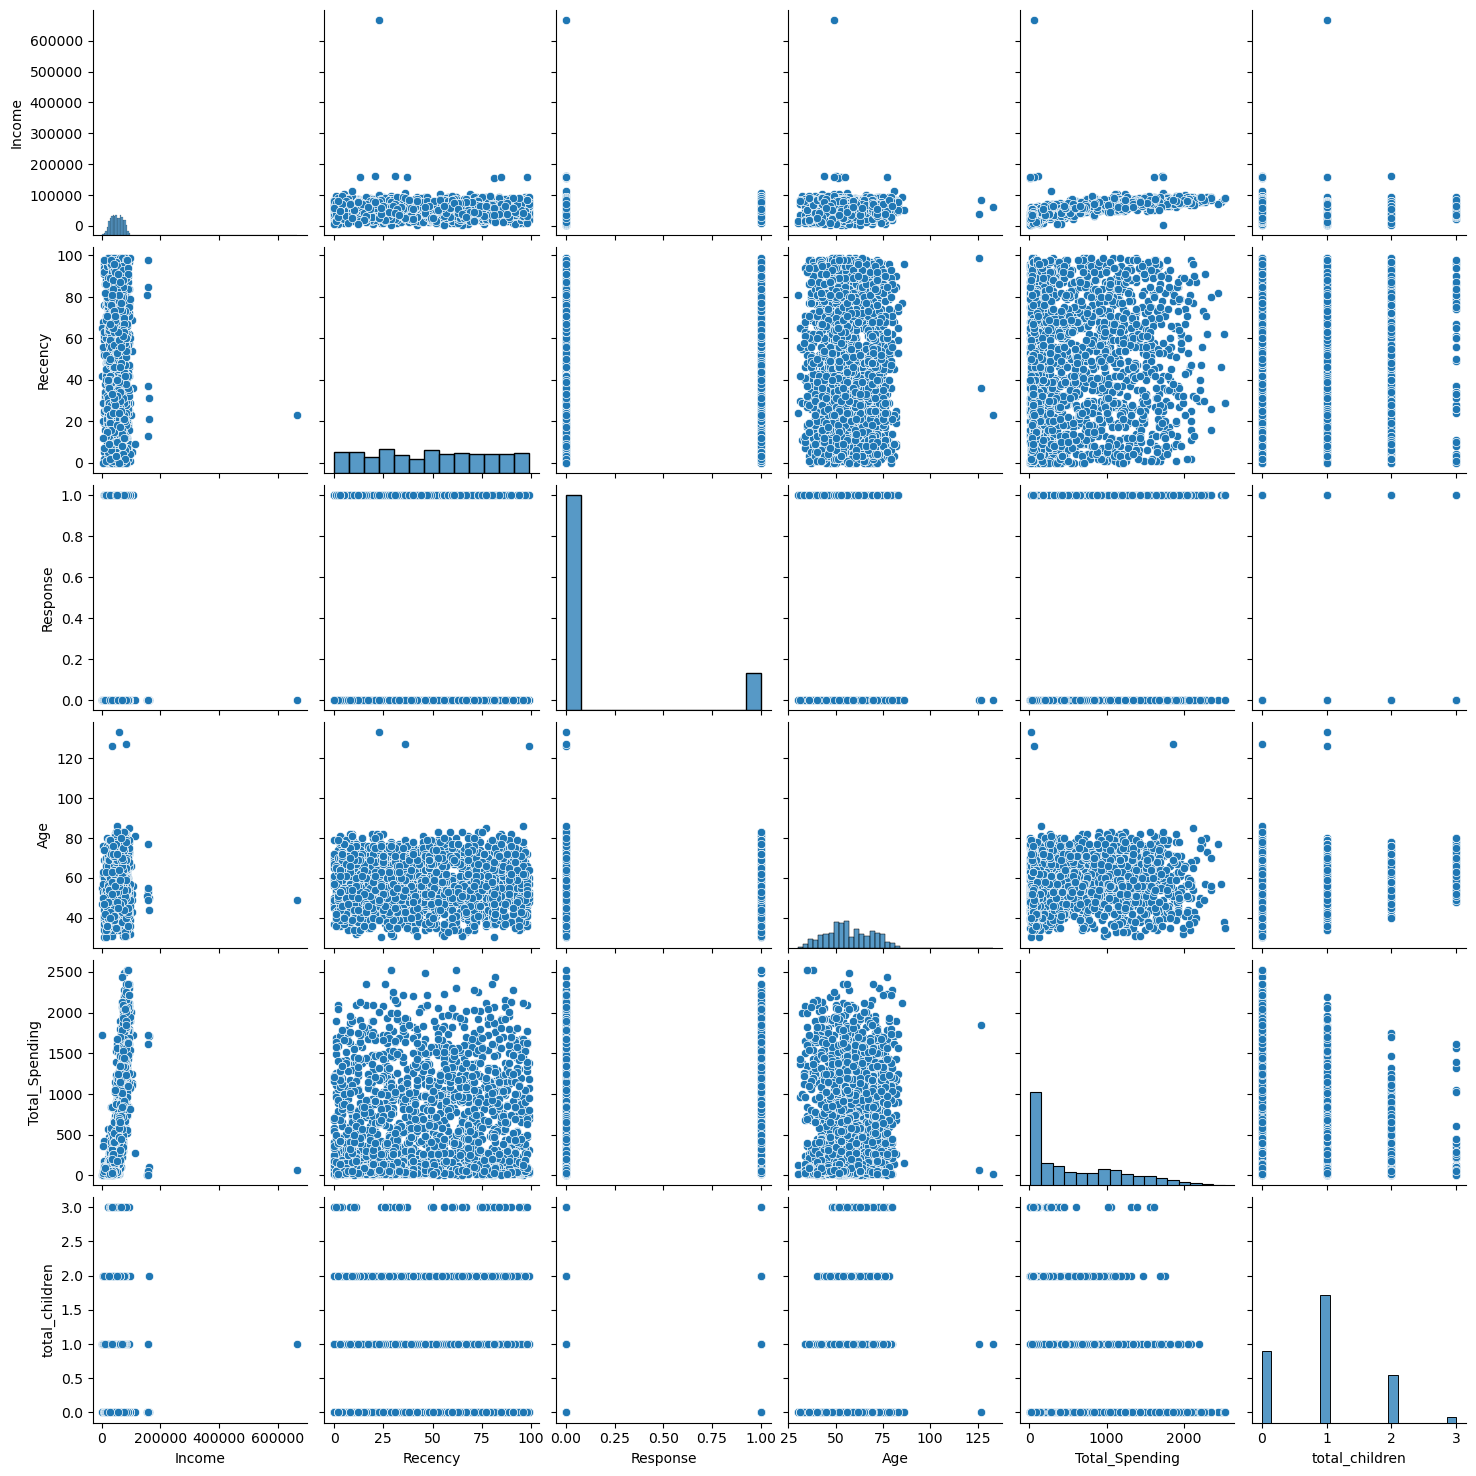

In [82]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "total_children"] 

#relative plots of some features - pair plots
sns.pairplot(df_cleaned[cols])

In [83]:
#Outlier to be removed
#1) income -> 600000+ 
#2) Age -> 120+
print("data size with outliers: ", len(df_cleaned))
df_cleaned = df_cleaned[(df_cleaned["Age"] < 90)] 
df_cleaned = df_cleaned[(df_cleaned["Income"] < 600_000)] 
print("data size without outliers: ", len(df_cleaned))

data size with outliers:  2240
data size without outliers:  2236


# Heatmap

<Axes: >

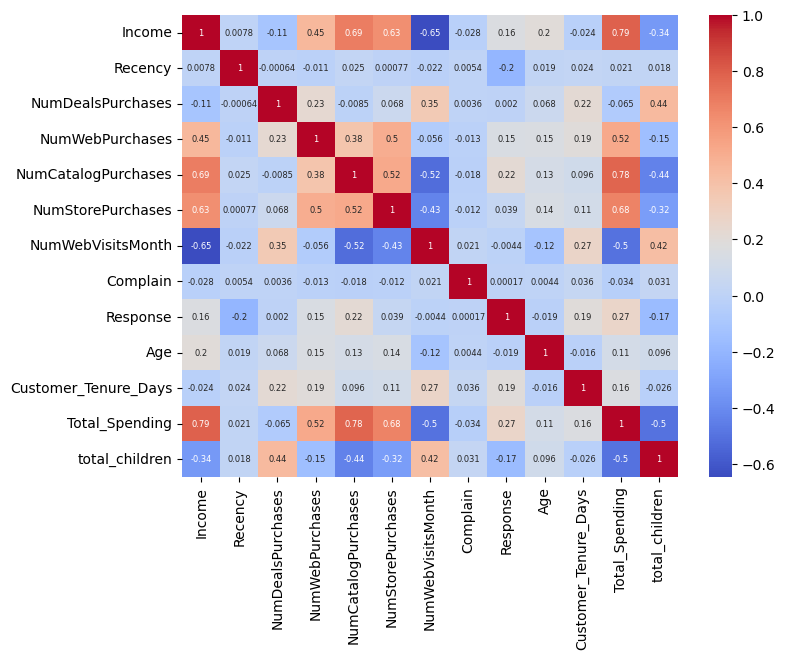

In [84]:
corr = df_cleaned.corr(numeric_only =True) 
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True, 
    annot_kws={"size": 6},
    cmap="coolwarm"
)

0.79 Income - total_spending
0.69 Income  - catalog_purchases
0.63 Income - store Purchase
-0.65 income - web visits -  high income earners dont visits websites 
0.78 spending - catalog_purchases
0.68 spending - NumStorePurchases 

# Encoding 

In [95]:
from sklearn.preprocessing import OneHotEncoder 
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_With"]
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])


In [96]:

enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [97]:
#embedding enc_cols into existising df
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols) ,enc_df], axis=1)

In [98]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,total_children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


# Scaling 

In [99]:
from sklearn.preprocessing import StandardScaler

X= df_encoded
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# Visualise


In [100]:
X_scaled.shape
#cant visualise in 18D thus using pca to visualise in 2d

(2236, 18)

C:\Users\vrajs\anaconda3\Lib\site-packages\matplotlib\collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


Text(0.5, 0.92, '3d projection')

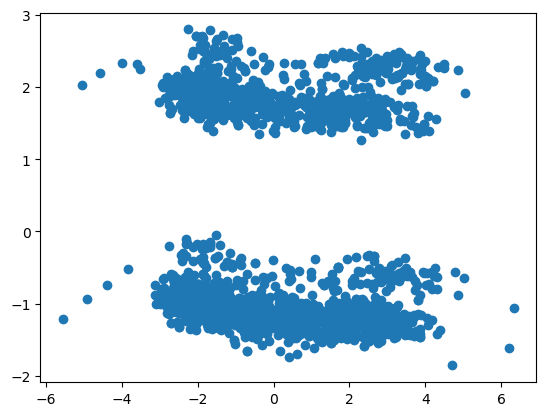

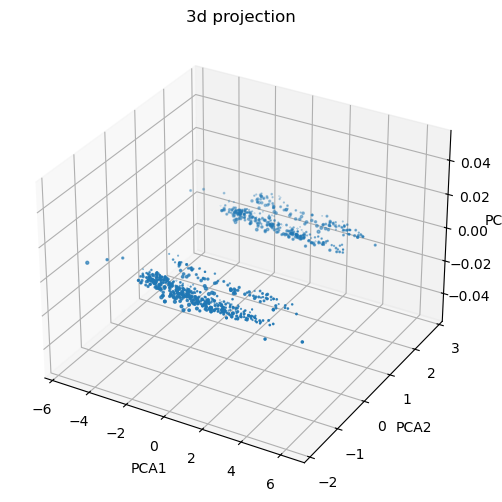

In [111]:
#2D
from sklearn.decomposition import PCA
pca = PCA(n_components = 3)
X_pca = pca.fit_transform(X_scaled)
#plot
plt.scatter(X_pca[:,0], X_pca[:,1])

#3d
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
plt.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

In [112]:
pca.explained_variance_ratio_ #for 3d

array([0.23163158, 0.11385454, 0.10405815])

# Analyse K Value

## 1. Elbow Method 

In [116]:
from sklearn.cluster import KMeans
from kneed import KneeLocator 

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)
    

In [117]:
knee = KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow

In [118]:
print("best k = ", optimal_k)

best k =  4


Text(0, 0.5, 'WCSS')

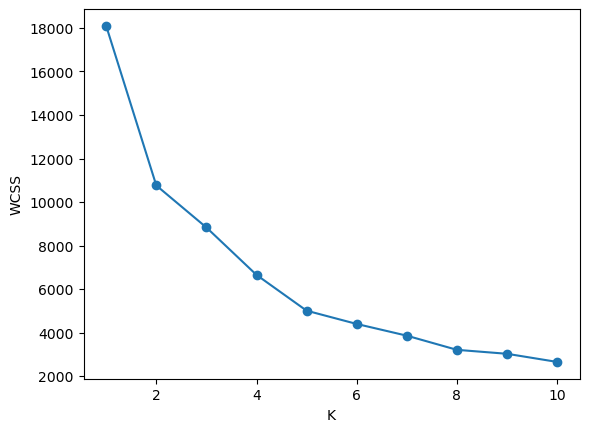

In [119]:
#plot
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")

# 2. Silhoette Score

Text(0, 0.5, 'Silhouette Score')

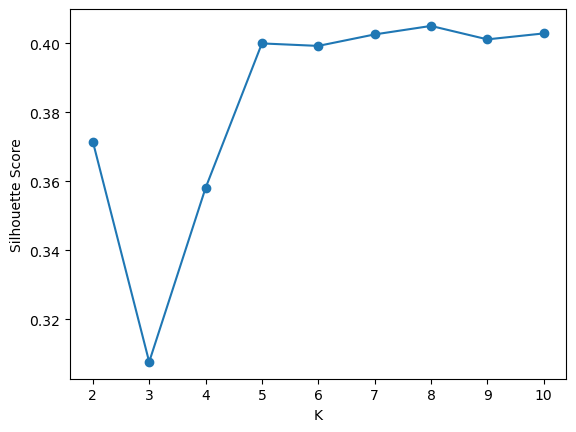

In [120]:
from sklearn.metrics import silhouette_score
scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score= silhouette_score(X_pca, labels)
    scores.append(score)
#plot
plt.plot(range(2,11), scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette Score")

Text(0, 0.5, 'SS')

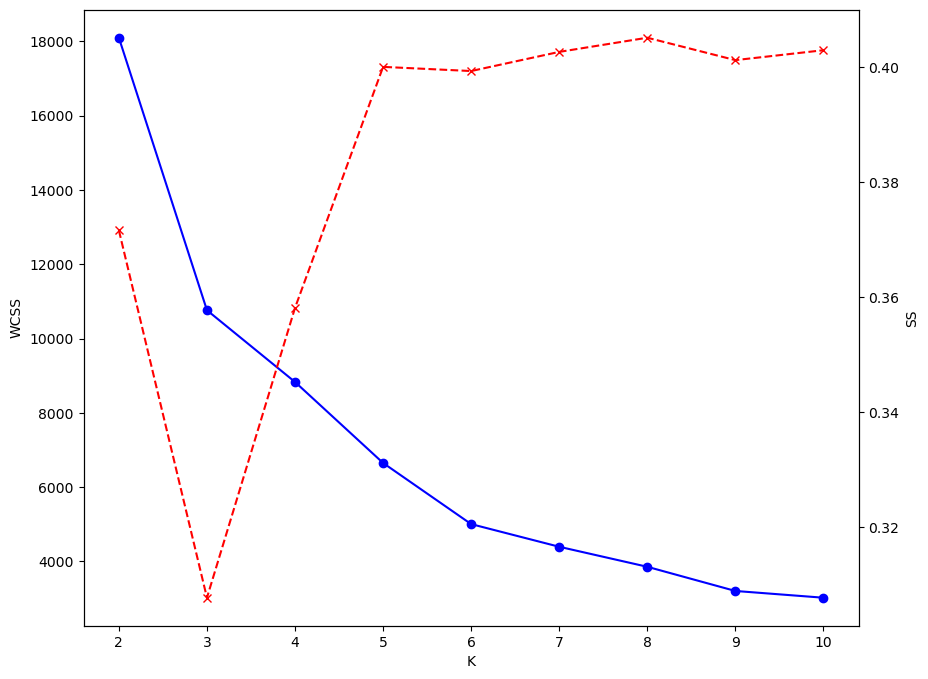

In [125]:
# combined plot
k_range = range(2,11) 
fig, ax1 = plt.subplots(figsize=(10,8))
ax1.plot(k_range,wcss[:len(k_range)], marker='o', color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("SS")

In [126]:
#intersection = optimal_k value hence k =4, we want to balance out both scores


# Clustering 

C:\Users\vrajs\anaconda3\Lib\site-packages\matplotlib\collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


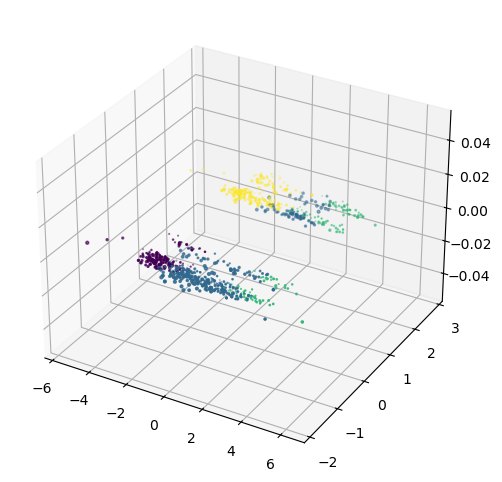

In [129]:
#K_Means 

kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection="3d")
plt.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=labels_kmeans)

In [130]:
# Agglomerative clustering
from sklearn.cluster import AgglomerativeClustering

C:\Users\vrajs\anaconda3\Lib\site-packages\matplotlib\collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


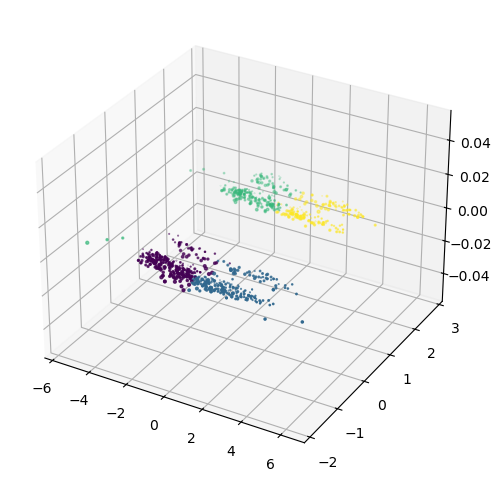

In [133]:
agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg_clf.fit_predict(X_pca)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
plt.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=labels_agg)

# Characterisation of Clusters/ Analysis 

In [146]:
X["cluster"] = labels_agg

In [147]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,total_children,Living_With,labels,cluster
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone,3,3
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone,2,2
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner,1,1
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner,0,0
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner,0,0


<Axes: xlabel='cluster', ylabel='count'>

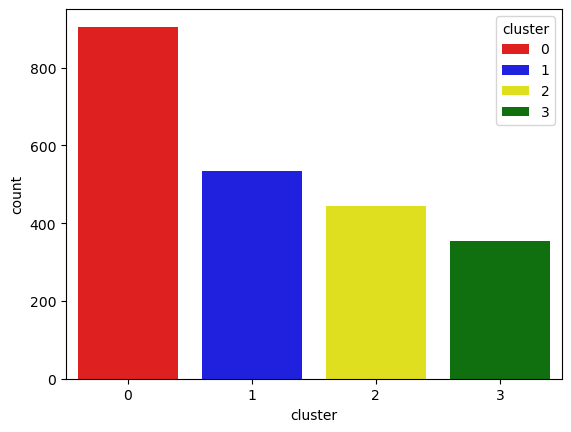

In [148]:
pal = ["red", "blue", "yellow", "green"]
sns.countplot(x=X["cluster"], palette=pal, hue=X["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

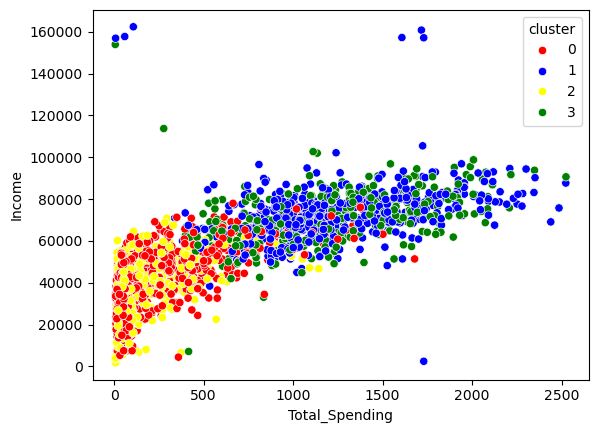

In [149]:
# Income & Spending patterns (as seen by heatmap)

sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue=X["cluster"], palette=pal)

In [151]:
#Cluster Summary
cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
cluster         